# Tech Challenge - Fase 1

## 1. Contexto e escopo da análise

Este notebook apresenta a exploração dos dados do e-commerce Olist, com foco na relação entre desempenho comercial, experiência logística e satisfação dos clientes.


### 1.1 Pergunta norteadora

**Clientes mais satisfeitos trazem maior receita?**

A pergunta será tratada como uma hipótese inicial. Caso os dados não sustentem essa relação, a análise seguirá os fatores que apresentarem maior relevância para explicar a satisfação dos clientes.


### 1.2 Bases utilizadas

Nesta exploração foram utilizadas principalmente as seguintes bases:

- `olist_orders_dataset.csv`: pedidos e datas do processo de compra e entrega;
- `olist_order_reviews_dataset.csv`: avaliações dos pedidos;
- `olist_order_items_dataset.csv`: itens, sellers, valores dos produtos e frete;
- `olist_customers_dataset.csv`: identificação e localização dos clientes.

Outras tabelas do conjunto de dados foram preservadas para possíveis análises futuras, mas não foram necessárias para responder às perguntas priorizadas neste notebook.


### 1.3 Premissas e definições da análise

Para manter consistência entre as análises, foram adotadas as seguintes regras:

- **Valor transacionado:** soma da coluna `price` dos itens de cada pedido. O valor não representa receita ou margem da Olist e não inclui o frete.
- **Satisfação:** medida pela coluna `review_score`, com notas de 1 a 5.
- **Avaliação baixa:** notas 1 ou 2.
- **Pedidos analisados em satisfação e logística:** pedidos com status `delivered`.
- **Múltiplas avaliações:** pedidos com mais de um review foram retirados da análise principal de satisfação para evitar ambiguidade na escolha da nota.
- **Pedido atrasado:** pedido cuja data real de entrega foi posterior à data estimada de entrega.
- **Sellers:** para análises de desempenho por seller, foram considerados somente pedidos associados a um único seller.
- **Comparação entre sellers:** foram considerados sellers com pelo menos 22 pedidos, valor correspondente ao 75º percentil da distribuição de volume.
- **Sellers de atenção:** sellers de maior valor transacionado que também apresentaram taxas de atraso e avaliações baixas acima do 75º percentil do grupo analisado.
- **Análise temporal:** os dados de 2016 foram mantidos na base, mas não utilizados como principal referência visual devido à baixa quantidade de registros. A leitura principal considera janeiro de 2017 a agosto de 2018.


## 2. Preparação e entendimento dos dados

Antes das análises, as bases são carregadas, inspecionadas e organizadas para que cada pergunta utilize uma população coerente.


### 2.1 Configuração do ambiente

In [1]:
import pandas as pd

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [225]:
import os

PASTA_GRAFICOS = '/content/drive/MyDrive/Tech_Challenge_Fase1/graficos'

os.makedirs(PASTA_GRAFICOS, exist_ok=True)

### 2.2 Base de pedidos

In [3]:
orders = pd.read_csv(
    '/content/drive/MyDrive/Tech_Challenge_Fase1/data/raw/olist_orders_dataset.csv'
)

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [6]:
orders.groupby('order_status')['order_id'].count()

,order_id
order_status,
approved,2
canceled,625
created,5
delivered,96478
invoiced,314
processing,301
shipped,1107
unavailable,609


In [7]:
orders['order_status'] == 'delivered'

,order_status
0,True
1,True
2,True
3,True
4,True
...,...
99436,True
99437,True
99438,True
99439,True


In [8]:
delivered_orders = orders[orders['order_status'] == 'delivered']

In [9]:
delivered_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [10]:
delivered_orders.shape

(96478, 8)

### 2.3 Base de avaliações

In [11]:
reviews = pd.read_csv(
    '/content/drive/MyDrive/Tech_Challenge_Fase1/data/raw/olist_order_reviews_dataset.csv'
)

In [12]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [13]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [14]:
reviews.groupby('review_score')['order_id'].count()

,order_id
review_score,
1,11424
2,3151
3,8179
4,19142
5,57328


### 2.4 Base de itens e valor dos pedidos

In [15]:
order_items = pd.read_csv(
    '/content/drive/MyDrive/Tech_Challenge_Fase1/data/raw/olist_order_items_dataset.csv'
)

In [16]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [17]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [18]:
items_por_pedido = order_items.groupby('order_id')['order_item_id'].count()

In [19]:
items_por_pedido.describe()

,order_item_id
count,98666.000000
mean,1.141731
std,0.538452
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,21.000000


In [20]:
valor_por_pedido = order_items.groupby('order_id')['price'].sum()

In [21]:
valor_por_pedido.head()

,price
order_id,
00010242fe8c5a6d1ba2dd792cb16214,58.90
00018f77f2f0320c557190d7a144bdd3,239.90
000229ec398224ef6ca0657da4fc703e,199.00
00024acbcdf0a6daa1e931b038114c75,12.99
00042b26cf59d7ce69dfabb4e55b4fd9,199.90


### 2.5 Tratamento de múltiplas avaliações

Antes de relacionar satisfação e valor, é necessário verificar se um mesmo pedido possui mais de uma avaliação registrada.


In [22]:
reviews['order_id'].count()

np.int64(99224)

In [23]:
reviews['order_id'].nunique()

98673

In [24]:
reviews_por_pedido = reviews.groupby('order_id')['review_id'].count()

In [25]:
reviews_por_pedido[reviews_por_pedido > 1].head()

,review_id
order_id,
0035246a40f520710769010f752e7507,2
013056cfe49763c6f66bda03396c5ee3,2
0176a6846bcb3b0d3aa3116a9a768597,2
02355020fd0a40a0d56df9f6ff060413,2
029863af4b968de1e5d6a82782e662f5,2


In [26]:
(reviews_por_pedido > 1).sum()

np.int64(547)

In [27]:
pedido_exemplo = reviews_por_pedido[reviews_por_pedido > 1].index[0]

pedido_exemplo

'0035246a40f520710769010f752e7507'

In [28]:
reviews[
    reviews['order_id'] == pedido_exemplo
]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12


In [29]:
maior_nota_por_pedido = reviews.groupby('order_id')['review_score'].max()

In [30]:
menor_nota_por_pedido = reviews.groupby('order_id')['review_score'].min()

In [31]:
diferenca_nota = maior_nota_por_pedido - menor_nota_por_pedido

In [32]:
(diferenca_nota > 0).sum()

np.int64(202)

In [33]:
contagem_reviews = reviews.groupby('order_id', as_index=False)['review_id'].count()

contagem_reviews.head()

,order_id,review_id
0,00010242fe8c5a6d1ba2dd792cb16214,1
1,00018f77f2f0320c557190d7a144bdd3,1
2,000229ec398224ef6ca0657da4fc703e,1
3,00024acbcdf0a6daa1e931b038114c75,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1


In [34]:
pedidos_um_review = contagem_reviews[
    contagem_reviews['review_id'] == 1
]

pedidos_um_review.head()

,order_id,review_id
0,00010242fe8c5a6d1ba2dd792cb16214,1
1,00018f77f2f0320c557190d7a144bdd3,1
2,000229ec398224ef6ca0657da4fc703e,1
3,00024acbcdf0a6daa1e931b038114c75,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1


In [35]:
reviews_limpos = pd.merge(
    reviews,
    pedidos_um_review[['order_id']],
    on='order_id',
    how='inner'
)

In [36]:
reviews_limpos.shape

(98126, 7)

### 2.6 Construção da base analítica

Nesta etapa, as informações de avaliação e valor são reunidas no nível do pedido e, em seguida, restringidas aos pedidos entregues.


In [37]:
valor_por_pedido = order_items.groupby('order_id', as_index=False)['price'].sum()

valor_por_pedido.head()

,order_id,price
0,00010242fe8c5a6d1ba2dd792cb16214,58.90
1,00018f77f2f0320c557190d7a144bdd3,239.90
2,000229ec398224ef6ca0657da4fc703e,199.00
3,00024acbcdf0a6daa1e931b038114c75,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90


In [38]:
base_satisfacao_valor = pd.merge(
    reviews_limpos[['order_id', 'review_score']],
    valor_por_pedido,
    on='order_id',
    how='inner'
)

In [39]:
base_satisfacao_valor.head()

,order_id,review_score,price
0,73fc7af87114b39712e6da79b0a377eb,4,370.00
1,a548910a1c6147796b98fdf73dbeba33,5,79.79
2,f9e4b658b201a9f2ecdecbb34bed034b,5,149.00
3,658677c97b385a9be170737859d3511b,5,179.99
4,8e6bfb81e283fa7e4f11123a3fb894f1,5,1199.00


In [40]:
base_satisfacao_valor.shape

(97373, 3)

In [41]:
base_analise = pd.merge(
    base_satisfacao_valor,
    delivered_orders[['order_id']],
    on='order_id',
    how='inner'
)

In [42]:
base_analise.head()

,order_id,review_score,price
0,73fc7af87114b39712e6da79b0a377eb,4,370.00
1,a548910a1c6147796b98fdf73dbeba33,5,79.79
2,f9e4b658b201a9f2ecdecbb34bed034b,5,149.00
3,658677c97b385a9be170737859d3511b,5,179.99
4,8e6bfb81e283fa7e4f11123a3fb894f1,5,1199.00


In [43]:
base_analise.shape

(95307, 3)

## 3. Satisfação x valor do pedido

A primeira análise testa a hipótese inicial do projeto: pedidos com maior satisfação apresentam maior valor?


### 3.1 Comparação do valor por nota

In [44]:
base_analise.groupby('review_score')['price'].mean()

,price
review_score,
1,165.365504
2,143.823454
3,127.596003
4,132.380331
5,134.738722


In [45]:
base_analise.groupby('review_score')['price'].median()

,price
review_score,
1,99.00
2,89.90
3,82.92
4,84.18
5,84.99


### 3.2 Distribuição dos valores e valores extremos

In [46]:
base_analise.groupby('review_score')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
review_score,,,,,,,,
1,9289.0,165.365504,288.340066,3.54,50.000,99.00,176.960,13440.0
2,2901.0,143.823454,216.312160,5.31,49.000,89.90,159.800,3999.0
3,7860.0,127.596003,168.037833,3.50,44.875,82.92,148.825,2919.4
4,18800.0,132.380331,195.065426,0.85,45.000,84.18,148.900,4690.0
5,56457.0,134.738722,200.703081,0.85,45.000,84.99,149.800,6735.0


In [47]:
import matplotlib.pyplot as plt

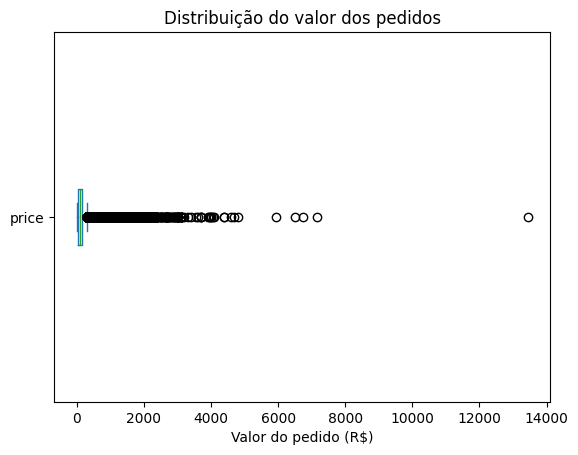

In [230]:
base_analise['price'].plot.box(vert=False)

plt.title('Distribuição do valor dos pedidos')
plt.xlabel('Valor do pedido (R$)')

plt.savefig(
    PASTA_GRAFICOS + '/03_valor_mediano_por_nota.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [49]:
q1 = base_analise['price'].quantile(0.25)
q3 = base_analise['price'].quantile(0.75)

iqr = q3 - q1

print('Q1:', q1)
print('Q3:', q3)
print('IQR:', iqr)

Q1: 45.9
Q3: 149.9
IQR: 104.0


In [50]:
limite_superior = q3 + 1.5 * iqr

print('Limite superior:', limite_superior)

Limite superior: 305.9


In [51]:
(base_analise['price'] > limite_superior).sum()

np.int64(7563)

### 3.3 Relação entre valor e satisfação

In [52]:
valor_mediano_por_nota = base_analise.groupby('review_score')['price'].median()

valor_mediano_por_nota

,price
review_score,
1,99.00
2,89.90
3,82.92
4,84.18
5,84.99


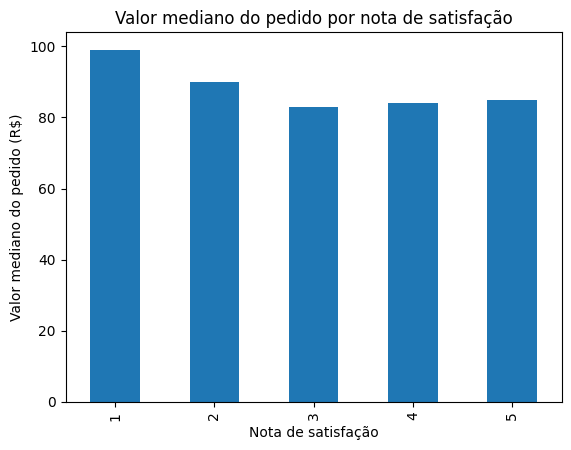

In [53]:
valor_mediano_por_nota.plot.bar()

plt.title('Valor mediano do pedido por nota de satisfação')
plt.xlabel('Nota de satisfação')
plt.ylabel('Valor mediano do pedido (R$)')
plt.show()

In [54]:
correlacao = base_analise['review_score'].corr(
    base_analise['price'],
    method='spearman'
)

correlacao

np.float64(-0.02880792364755008)

### 3.4 Conclusão - Satisfação x valor do pedido

A análise não mostrou evidência de que pedidos com maior nota de satisfação apresentem maior valor.

As medianas dos pedidos permaneceram próximas entre as notas 3, 4 e 5, enquanto os pedidos com nota 1 apresentaram a maior mediana.

A correlação de Spearman entre a nota de satisfação e o valor do pedido foi de aproximadamente -0,03, indicando uma relação praticamente inexistente.

Portanto, o valor do pedido, isoladamente, não parece explicar a satisfação dos clientes na base analisada.


## 4. Prazo de entrega x satisfação

Como o valor do pedido não apresentou relação relevante com a satisfação, a análise passa a investigar o desempenho logístico.


### 4.1 Preparação das datas e definição de atraso

In [55]:
orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date']
)

In [56]:
orders[
    [
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
].dtypes

,0
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [57]:
pedidos_entregues = orders[
    orders['order_status'] == 'delivered'
].copy()

In [58]:
pedidos_entregues[
    'order_delivered_customer_date'
].isna().sum()

np.int64(8)

In [59]:
pedidos_entregues = pedidos_entregues.dropna(
    subset=['order_delivered_customer_date']
)

In [60]:
pedidos_entregues.shape

(96470, 8)

In [61]:
pedidos_entregues['diferenca_entrega_dias'] = (
    pedidos_entregues['order_delivered_customer_date']
    - pedidos_entregues['order_estimated_delivery_date']
).dt.days

In [62]:
pedidos_entregues[
    [
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
        'diferenca_entrega_dias'
    ]
].head()

,order_delivered_customer_date,order_estimated_delivery_date,diferenca_entrega_dias
0,2017-10-10 21:25:13,2017-10-18,-8
1,2018-08-07 15:27:45,2018-08-13,-6
2,2018-08-17 18:06:29,2018-09-04,-18
3,2017-12-02 00:28:42,2017-12-15,-13
4,2018-02-16 18:17:02,2018-02-26,-10


In [63]:
pedidos_entregues.shape

(96470, 9)

In [64]:
pedidos_entregues['atrasado'] = (
    pedidos_entregues['diferenca_entrega_dias'] > 0
)

In [65]:
pedidos_entregues.groupby('atrasado')['order_id'].count()

,order_id
atrasado,
False,89936
True,6534


### 4.2 Atraso x satisfação

In [66]:
base_entrega_satisfacao = pd.merge(
    pedidos_entregues[
        ['order_id', 'atrasado', 'diferenca_entrega_dias']
    ],
    reviews_limpos[
        ['order_id', 'review_score']
    ],
    on='order_id',
    how='inner'
)

In [67]:
base_entrega_satisfacao.head()

,order_id,atrasado,diferenca_entrega_dias,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,False,-8,4
1,53cdb2fc8bc7dce0b6741e2150273451,False,-6,4
2,47770eb9100c2d0c44946d9cf07ec65d,False,-18,5
3,949d5b44dbf5de918fe9c16f97b45f8a,False,-13,5
4,ad21c59c0840e6cb83a9ceb5573f8159,False,-10,5


In [68]:
base_entrega_satisfacao.shape

(95299, 4)

In [69]:
base_entrega_satisfacao.groupby('atrasado')['review_score'].mean()

,review_score
atrasado,
False,4.291165
True,2.272627


In [70]:
base_entrega_satisfacao.groupby('atrasado')['review_score'].median()

,review_score
atrasado,
False,5.0
True,1.0


In [71]:
base_entrega_satisfacao.groupby(['atrasado','review_score'])['order_id'].count()

atrasado  review_score
False     1                5873
          2                2354
          3                7171
          4               18152
          5               55396
True      1                3415
          2                 547
          3                 689
          4                 648
          5                1054
Name: order_id, dtype: int64

In [72]:
avaliacoes_baixas = base_entrega_satisfacao[
    base_entrega_satisfacao['review_score'] <= 2
]

In [73]:
avaliacoes_baixas.groupby('atrasado')['order_id'].count()

,order_id
atrasado,
False,8227
True,3962


In [74]:
base_entrega_satisfacao.groupby('atrasado')['order_id'].count()

,order_id
atrasado,
False,88946
True,6353


In [75]:
percentual_baixas = (
    avaliacoes_baixas.groupby('atrasado')['order_id'].count()
    /
    base_entrega_satisfacao.groupby('atrasado')['order_id'].count()
    * 100
)

percentual_baixas

,order_id
atrasado,
False,9.249432
True,62.364237


#### Leitura inicial

Pedidos atrasados apresentaram uma proporção muito maior de avaliações baixas: cerca de 62% receberam notas 1 ou 2, contra aproximadamente 9% entre os pedidos sem atraso.


In [76]:
percentual_baixas_grafico = percentual_baixas.copy()

percentual_baixas_grafico.index = [
    'Sem atraso',
    'Atrasado'
]

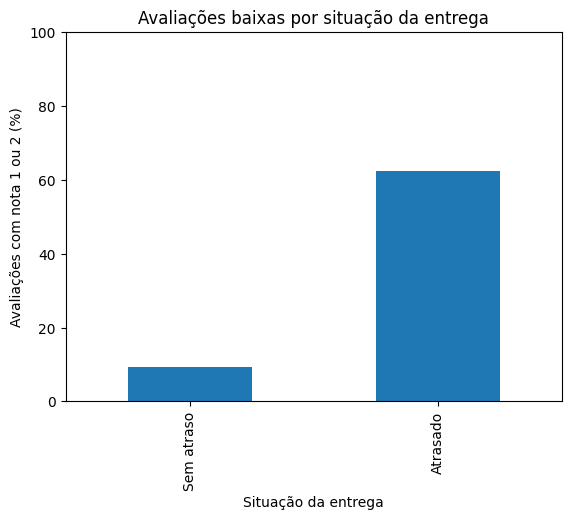

In [226]:
percentual_baixas_grafico.plot.bar()

plt.title('Avaliações baixas por situação da entrega')
plt.xlabel('Situação da entrega')
plt.ylabel('Avaliações com nota 1 ou 2 (%)')
plt.ylim(0, 100)

plt.savefig(
    PASTA_GRAFICOS + '/04_avaliacoes_baixas_situacao_entrega.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### 4.3 Intensidade do atraso

#### Entre os pedidos que atrasaram, quanto maior o atraso, pior tende a ser a avaliação?


In [78]:
somente_atrasados = base_entrega_satisfacao[
    base_entrega_satisfacao['atrasado'] == True
]

In [79]:
correlacao_atraso = somente_atrasados[
    'diferenca_entrega_dias'
].corr(
    somente_atrasados['review_score'],
    method='spearman'
)

correlacao_atraso

np.float64(-0.4024507786896166)

In [80]:
somente_atrasados.shape

(6353, 4)

Entre os pedidos atrasados, foi observada uma correlação de Spearman de aproximadamente -0,40 entre os dias de atraso e a nota de satisfação.

O resultado indica uma associação negativa: quanto maior o atraso, menor tende a ser a avaliação do pedido.


#### Como muda a satisfação quando o atraso é de poucos dias versus atrasos maiores?

In [81]:
atraso_1_3 = somente_atrasados[
    somente_atrasados['diferenca_entrega_dias'] <= 3
]

atraso_1_3.shape

(1848, 4)

In [82]:
atraso_4_7 = somente_atrasados[
    (somente_atrasados['diferenca_entrega_dias'] > 3)
    &
    (somente_atrasados['diferenca_entrega_dias'] <= 7)
]

In [83]:
atraso_1_3 = somente_atrasados[
    somente_atrasados['diferenca_entrega_dias'] <= 3
]

atraso_4_7 = somente_atrasados[
    (somente_atrasados['diferenca_entrega_dias'] > 3)
    &
    (somente_atrasados['diferenca_entrega_dias'] <= 7)
]

atraso_8_14 = somente_atrasados[
    (somente_atrasados['diferenca_entrega_dias'] > 7)
    &
    (somente_atrasados['diferenca_entrega_dias'] <= 14)
]

atraso_15_mais = somente_atrasados[
    somente_atrasados['diferenca_entrega_dias'] > 14
]

In [84]:
print('1 a 3 dias:', atraso_1_3.shape[0])
print('4 a 7 dias:', atraso_4_7.shape[0])
print('8 a 14 dias:', atraso_8_14.shape[0])
print('15 dias ou mais:', atraso_15_mais.shape[0])

1 a 3 dias: 1848
4 a 7 dias: 1740
8 a 14 dias: 1440
15 dias ou mais: 1325


In [85]:
(
    atraso_1_3.shape[0]
    + atraso_4_7.shape[0]
    + atraso_8_14.shape[0]
    + atraso_15_mais.shape[0]
)

6353

#### Como a nota de satisfação muda conforme o atraso aumenta?

In [86]:
print('1 a 3 dias:', atraso_1_3['review_score'].mean())
print('4 a 7 dias:', atraso_4_7['review_score'].mean())
print('8 a 14 dias:', atraso_8_14['review_score'].mean())
print('15 dias ou mais:', atraso_15_mais['review_score'].mean())

1 a 3 dias: 3.292207792207792
4 a 7 dias: 2.106896551724138
8 a 14 dias: 1.6666666666666667
15 dias ou mais: 1.7267924528301888


In [87]:
print('1 a 3 dias:', atraso_1_3['review_score'].median())
print('4 a 7 dias:', atraso_4_7['review_score'].median())
print('8 a 14 dias:', atraso_8_14['review_score'].median())
print('15 dias ou mais:', atraso_15_mais['review_score'].median())

1 a 3 dias: 4.0
4 a 7 dias: 1.0
8 a 14 dias: 1.0
15 dias ou mais: 1.0


#### Leitura das faixas de atraso

Os pedidos com atraso de 1 a 3 dias apresentaram nota média de aproximadamente 3,29 e mediana 4.

A partir da faixa de 4 a 7 dias, a mediana caiu para 1 e permaneceu nesse nível nas faixas de atraso seguintes.

Embora a média não diminua de forma perfeitamente contínua em todas as faixas, o comportamento geral indica que atrasos maiores estão associados a avaliações mais baixas.


#### Percentual de avaliações 1 ou 2 por faixa de atraso

In [88]:
baixas_1_3 = atraso_1_3[
    atraso_1_3['review_score'] <= 2
]

percentual_1_3 = (
    len(baixas_1_3) / len(atraso_1_3) * 100
)

percentual_1_3

32.142857142857146

In [89]:
baixas_4_7 = atraso_4_7[
    atraso_4_7['review_score'] <= 2
]

percentual_4_7 = (
    len(baixas_4_7) / len(atraso_4_7) * 100
)

In [90]:
baixas_8_14 = atraso_8_14[
    atraso_8_14['review_score'] <= 2
]

percentual_8_14 = (
    len(baixas_8_14) / len(atraso_8_14) * 100
)

In [91]:
baixas_15_mais = atraso_15_mais[
    atraso_15_mais['review_score'] <= 2
]

percentual_15_mais = (
    len(baixas_15_mais) / len(atraso_15_mais) * 100
)

In [92]:
print('1 a 3 dias:', percentual_1_3)
print('4 a 7 dias:', percentual_4_7)
print('8 a 14 dias:', percentual_8_14)
print('15 dias ou mais:', percentual_15_mais)

1 a 3 dias: 32.142857142857146
4 a 7 dias: 67.52873563218391
8 a 14 dias: 80.27777777777779
15 dias ou mais: 78.26415094339623


A proporção de avaliações baixas aumenta fortemente nas primeiras faixas de atraso e permanece em patamar muito elevado nos atrasos superiores a 8 dias.


#### Visualização das avaliações baixas por faixa de atraso

In [93]:
faixas_atraso = [
    '1 a 3 dias',
    '4 a 7 dias',
    '8 a 14 dias',
    '15 dias ou mais'
]

percentuais_baixos = [
    percentual_1_3,
    percentual_4_7,
    percentual_8_14,
    percentual_15_mais
]

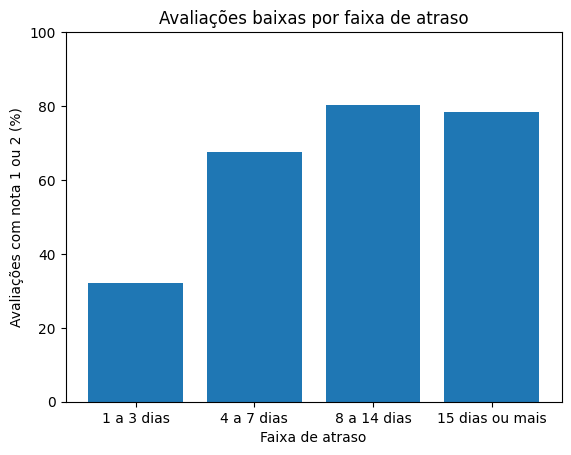

In [231]:
plt.bar(
    faixas_atraso,
    percentuais_baixos
)

plt.title('Avaliações baixas por faixa de atraso')
plt.xlabel('Faixa de atraso')
plt.ylabel('Avaliações com nota 1 ou 2 (%)')
plt.ylim(0, 100)

plt.savefig(
    PASTA_GRAFICOS + '/04_avaliacoes_baixas_faixa_atraso.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### 4.4 Conclusão - Prazo de entrega x satisfação

A análise mostrou uma diferença relevante na satisfação entre pedidos entregues no prazo e pedidos atrasados.

Os pedidos sem atraso apresentaram nota média de aproximadamente 4,29 e mediana 5, enquanto os pedidos atrasados apresentaram média de aproximadamente 2,27 e mediana 1.

Além disso, cerca de 62% dos pedidos atrasados receberam notas 1 ou 2, contra aproximadamente 9% entre os pedidos sem atraso.

Entre os pedidos atrasados, a correlação de Spearman entre os dias de atraso e a nota foi de aproximadamente -0,40, indicando uma associação negativa: atrasos maiores tendem a estar relacionados a avaliações menores.

Ao analisar faixas de atraso, a proporção de avaliações 1 ou 2 aumentou de aproximadamente 32% nos atrasos de 1 a 3 dias para cerca de 68% entre 4 e 7 dias, permanecendo próxima de 80% nos atrasos superiores a 8 dias.

Os resultados indicam uma associação relevante entre o cumprimento do prazo de entrega e a satisfação dos clientes. A análise não permite afirmar, isoladamente, que o atraso seja a única causa das avaliações negativas.


## 5. Análise geográfica

### 5.1 Volume e taxa de atraso por estado

A análise geográfica começa pelo volume de pedidos e pela proporção de atrasos em cada estado, evitando interpretar apenas quantidades absolutas.


In [95]:
customers = pd.read_csv(
    '/content/drive/MyDrive/Tech_Challenge_Fase1/data/raw/olist_customers_dataset.csv'
)

In [96]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [97]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [98]:
base_entrega_cliente = pd.merge(
    base_entrega_satisfacao,
    orders[['order_id', 'customer_id']],
    on='order_id',
    how='inner'
)

In [99]:
base_entrega_cliente.head()

,order_id,atrasado,diferenca_entrega_dias,review_score,customer_id
0,e481f51cbdc54678b7cc49136f2d6af7,False,-8,4,9ef432eb6251297304e76186b10a928d
1,53cdb2fc8bc7dce0b6741e2150273451,False,-6,4,b0830fb4747a6c6d20dea0b8c802d7ef
2,47770eb9100c2d0c44946d9cf07ec65d,False,-18,5,41ce2a54c0b03bf3443c3d931a367089
3,949d5b44dbf5de918fe9c16f97b45f8a,False,-13,5,f88197465ea7920adcdbec7375364d82
4,ad21c59c0840e6cb83a9ceb5573f8159,False,-10,5,8ab97904e6daea8866dbdbc4fb7aad2c


In [100]:
base_entrega_cliente.shape

(95299, 5)

In [101]:
base_entrega_estado = pd.merge(
    base_entrega_cliente,
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='inner'
)

In [102]:
base_entrega_estado.head()

,order_id,atrasado,diferenca_entrega_dias,review_score,customer_id,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,False,-8,4,9ef432eb6251297304e76186b10a928d,SP
1,53cdb2fc8bc7dce0b6741e2150273451,False,-6,4,b0830fb4747a6c6d20dea0b8c802d7ef,BA
2,47770eb9100c2d0c44946d9cf07ec65d,False,-18,5,41ce2a54c0b03bf3443c3d931a367089,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,False,-13,5,f88197465ea7920adcdbec7375364d82,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,False,-10,5,8ab97904e6daea8866dbdbc4fb7aad2c,SP


In [103]:
base_entrega_estado.shape

(95299, 6)

In [104]:
pedidos_por_estado = base_entrega_estado.groupby(
    'customer_state'
)['order_id'].count()

pedidos_por_estado

,order_id
customer_state,
AC,80
AL,390
AM,143
AP,66
BA,3212
CE,1270
DF,2051
ES,1960
GO,1929


In [105]:
atrasados = base_entrega_estado[
    base_entrega_estado['atrasado'] == True
]

In [106]:
atrasados_por_estado = atrasados.groupby(
    'customer_state'
)['order_id'].count()

atrasados_por_estado

,order_id
customer_state,
AC,3
AL,81
AM,4
AP,2
BA,380
CE,173
DF,118
ES,205
GO,122


In [107]:
taxa_atraso_estado = (
    atrasados_por_estado
    /
    pedidos_por_estado
    * 100
)

taxa_atraso_estado

,order_id
customer_state,
AC,3.750000
AL,20.769231
AM,2.797203
AP,3.030303
BA,11.830635
CE,13.622047
DF,5.753291
ES,10.459184
GO,6.324520


Estados com taxas de atraso maiores nem sempre possuem grande volume de pedidos. Por isso, a interpretação deve considerar também a quantidade de observações em cada estado.


### 5.2 Avaliações baixas por estado

In [108]:
avaliacoes_baixas_estado = base_entrega_estado[
    base_entrega_estado['review_score'] <= 2
]

In [109]:
baixas_por_estado = avaliacoes_baixas_estado.groupby(
    'customer_state'
)['order_id'].count()

baixas_por_estado

,order_id
customer_state,
AC,12
AL,82
AM,18
AP,4
BA,547
CE,217
DF,270
ES,271
GO,255


In [110]:
taxa_baixas_estado = (
    baixas_por_estado
    /
    pedidos_por_estado
    * 100
)

taxa_baixas_estado

,order_id
customer_state,
AC,15.000000
AL,21.025641
AM,12.587413
AP,6.060606
BA,17.029888
CE,17.086614
DF,13.164310
ES,13.826531
GO,13.219285


In [111]:
resumo_estado = pd.concat(
    [
        pedidos_por_estado,
        taxa_atraso_estado,
        taxa_baixas_estado
    ],
    axis=1
)

In [112]:
resumo_estado.columns = [
    'quantidade_pedidos',
    'taxa_atraso',
    'taxa_avaliacoes_baixas'
]

In [113]:
resumo_estado

,quantidade_pedidos,taxa_atraso,taxa_avaliacoes_baixas
customer_state,,,
AC,80,3.750000,15.000000
AL,390,20.769231,21.025641
AM,143,2.797203,12.587413
AP,66,3.030303,6.060606
BA,3212,11.830635,17.029888
CE,1270,13.622047,17.086614
DF,2051,5.753291,13.164310
ES,1960,10.459184,13.826531
GO,1929,6.324520,13.219285


#### Leitura inicial por estado

As taxas de atraso e de avaliações baixas variam entre os estados.

Estados com taxas elevadas nem sempre possuem grande volume de pedidos, por isso a leitura deve considerar também a quantidade de observações.

O Rio de Janeiro se destaca por combinar alto volume de pedidos com taxas relativamente elevadas de atraso e avaliações baixas.

Bahia e Ceará também apresentam indicadores de atenção, embora com volumes menores do que RJ, MG e SP.


### 5.3 Relação entre atraso, satisfação e exposição financeira

In [114]:
base_estado_valor = pd.merge(
    base_entrega_estado,
    valor_por_pedido,
    on='order_id',
    how='inner'
)

In [115]:
base_estado_valor.head()

,order_id,atrasado,diferenca_entrega_dias,review_score,customer_id,customer_state,price
0,e481f51cbdc54678b7cc49136f2d6af7,False,-8,4,9ef432eb6251297304e76186b10a928d,SP,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,False,-6,4,b0830fb4747a6c6d20dea0b8c802d7ef,BA,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,False,-18,5,41ce2a54c0b03bf3443c3d931a367089,GO,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,False,-13,5,f88197465ea7920adcdbec7375364d82,RN,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,False,-10,5,8ab97904e6daea8866dbdbc4fb7aad2c,SP,19.90


In [116]:
base_estado_valor.shape

(95299, 7)

In [117]:
valor_por_estado = base_estado_valor.groupby(
    'customer_state'
)['price'].sum()

valor_por_estado

,price
customer_state,
AC,15930.97
AL,77204.97
AM,22029.95
AP,13328.91
BA,488357.25
CE,218095.44
DF,293439.31
ES,256656.22
GO,276335.39


#### Onde o problema de experiência coincide com maior exposição de valor?

In [118]:
resumo_estado['valor_transacionado'] = valor_por_estado

In [119]:
resumo_estado

,quantidade_pedidos,taxa_atraso,taxa_avaliacoes_baixas,valor_transacionado
customer_state,,,,
AC,80,3.750000,15.000000,15930.97
AL,390,20.769231,21.025641,77204.97
AM,143,2.797203,12.587413,22029.95
AP,66,3.030303,6.060606,13328.91
BA,3212,11.830635,17.029888,488357.25
CE,1270,13.622047,17.086614,218095.44
DF,2051,5.753291,13.164310,293439.31
ES,1960,10.459184,13.826531,256656.22
GO,1929,6.324520,13.219285,276335.39


#### Leitura combinada por estado

A análise por estado mostra que taxas elevadas de atraso ou avaliações baixas devem ser interpretadas juntamente com o volume de pedidos e o valor transacionado.

Alagoas apresenta algumas das maiores taxas observadas, porém com um volume relativamente pequeno de pedidos.

O Rio de Janeiro se destaca por combinar volume elevado, valor transacionado relevante e taxas altas de atraso e avaliações baixas.

Minas Gerais possui volume semelhante ao Rio de Janeiro, mas apresenta indicadores de atraso e insatisfação consideravelmente menores.

Bahia também apresenta taxas elevadas de atraso e avaliações baixas, embora com menor volume de pedidos e valor transacionado.

Esses resultados sugerem que a priorização de ações deve considerar simultaneamente o tamanho da operação e os indicadores de experiência.


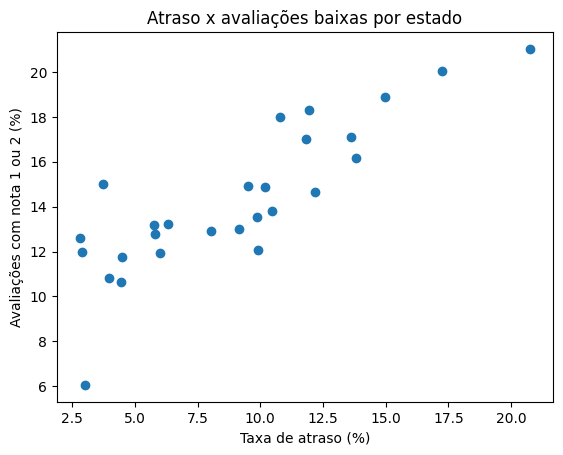

In [234]:
plt.scatter(
    resumo_estado['taxa_atraso'],
    resumo_estado['taxa_avaliacoes_baixas']
)

plt.title('Atraso x avaliações baixas por estado')
plt.xlabel('Taxa de atraso (%)')
plt.ylabel('Avaliações com nota 1 ou 2 (%)')

plt.savefig(
    PASTA_GRAFICOS + '/05_atraso_avaliacoes_baixas_estado.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [121]:
correlacao_estados = resumo_estado['taxa_atraso'].corr(
    resumo_estado['taxa_avaliacoes_baixas'],
    method='spearman'
)

correlacao_estados

np.float64(0.8284493284493284)

#### Relação entre taxa de atraso e avaliações baixas

A correlação de Spearman entre a taxa de atraso dos estados e a proporção de avaliações com notas 1 ou 2 foi de aproximadamente 0,83, indicando uma associação positiva forte.

Estados com maior percentual de pedidos atrasados também tendem a apresentar maior percentual de avaliações baixas.

Entretanto, os estados possuem volumes de pedidos muito diferentes, por isso esse resultado deve ser interpretado junto com a quantidade de pedidos e o valor transacionado.


### 5.4 Valor associado a atraso e avaliação baixa

In [122]:
pedidos_experiencia_ruim = base_estado_valor[
    (base_estado_valor['atrasado'] == True)
    &
    (base_estado_valor['review_score'] <= 2)
]

In [123]:
pedidos_experiencia_ruim.shape

(3962, 7)

In [124]:
valor_experiencia_ruim = pedidos_experiencia_ruim['price'].sum()

valor_experiencia_ruim

np.float64(616402.96)

In [125]:
valor_total_analisado = base_estado_valor['price'].sum()

valor_total_analisado

np.float64(13050661.68)

In [126]:
percentual_valor_experiencia_ruim = (
    valor_experiencia_ruim
    /
    valor_total_analisado
    * 100
)

percentual_valor_experiencia_ruim

np.float64(4.723154849264317)

#### Valor associado a experiências com atraso e baixa satisfação

Foram identificados 3.962 pedidos que apresentaram simultaneamente atraso na entrega e avaliação com nota 1 ou 2.

Esses pedidos somaram aproximadamente R$ 616 mil em valor transacionado, o equivalente a cerca de 4,7% do valor total analisado.

Esse montante não representa receita perdida, mas indica o volume financeiro associado a pedidos com sinais de experiência negativa.


#### Em quais estados está concentrado esse valor?

In [127]:
valor_ruim_por_estado = pedidos_experiencia_ruim.groupby(
    'customer_state'
)['price'].sum()

valor_ruim_por_estado

,price
customer_state,
AC,1274.99
AL,11444.41
AM,606.88
BA,40044.99
CE,20098.63
DF,10892.23
ES,14869.24
GO,9210.39
MA,15985.77


#### Qual percentual do valor transacionado de cada estado está associado a atraso + avaliação baixa?

In [128]:
percentual_valor_ruim_estado = (
    valor_ruim_por_estado
    /
    valor_por_estado
    * 100
)

percentual_valor_ruim_estado

,price
customer_state,
AC,8.003216
AL,14.823411
AM,2.754795
AP,NaN
BA,8.199938
CE,9.215521
DF,3.711919
ES,5.793446
GO,3.333048


In [129]:
percentual_valor_ruim_estado = percentual_valor_ruim_estado.fillna(0)

In [130]:
resumo_estado['valor_experiencia_ruim'] = valor_ruim_por_estado
resumo_estado['percentual_valor_experiencia_ruim'] = percentual_valor_ruim_estado

In [131]:
resumo_estado['valor_experiencia_ruim'] = (
    resumo_estado['valor_experiencia_ruim'].fillna(0)
)

In [132]:
resumo_estado

,quantidade_pedidos,taxa_atraso,taxa_avaliacoes_baixas,valor_transacionado,valor_experiencia_ruim,percentual_valor_experiencia_ruim
customer_state,,,,,,
AC,80,3.750000,15.000000,15930.97,1274.99,8.003216
AL,390,20.769231,21.025641,77204.97,11444.41,14.823411
AM,143,2.797203,12.587413,22029.95,606.88,2.754795
AP,66,3.030303,6.060606,13328.91,0.00,0.000000
BA,3212,11.830635,17.029888,488357.25,40044.99,8.199938
CE,1270,13.622047,17.086614,218095.44,20098.63,9.215521
DF,2051,5.753291,13.164310,293439.31,10892.23,3.711919
ES,1960,10.459184,13.826531,256656.22,14869.24,5.793446
GO,1929,6.324520,13.219285,276335.39,9210.39,3.333048


### 5.5 Conclusão - Análise geográfica

A análise do valor transacionado mostra que experiências com atraso e avaliações baixas devem ser interpretadas tanto em valores absolutos quanto proporcionalmente.

São Paulo concentra o maior valor absoluto associado a essas experiências, mas esse montante representa uma parcela relativamente menor do valor total transacionado no estado.

O Rio de Janeiro apresenta uma combinação relevante de alto volume financeiro, taxas elevadas de atraso e avaliações baixas e uma proporção maior do valor transacionado associada a experiências negativas.

Estados com percentuais ainda maiores, como Alagoas, Maranhão e Sergipe, possuem volumes menores e devem ser interpretados considerando essa diferença de escala.


## 6. Análise de sellers

A análise de sellers busca identificar grupos que combinem relevância financeira e indicadores desfavoráveis de atraso e satisfação.


### 6.1 Preparação da população de sellers

Como um mesmo pedido pode conter itens de mais de um seller, primeiro é verificado quantos sellers diferentes existem em cada pedido.


In [133]:
sellers_por_pedido = order_items.groupby(
    'order_id'
)['seller_id'].nunique()

sellers_por_pedido.head()

,seller_id
order_id,
00010242fe8c5a6d1ba2dd792cb16214,1
00018f77f2f0320c557190d7a144bdd3,1
000229ec398224ef6ca0657da4fc703e,1
00024acbcdf0a6daa1e931b038114c75,1
00042b26cf59d7ce69dfabb4e55b4fd9,1


In [134]:
sellers_por_pedido.describe()

,seller_id
count,98666.000000
mean,1.013622
std,0.122297
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,5.000000


In [135]:
(sellers_por_pedido > 1).sum()

np.int64(1278)

Para evitar atribuir a mesma avaliação a diferentes vendedores do mesmo pedido, a análise de sellers considera somente pedidos associados a um único seller.


In [136]:
pedidos_um_seller = sellers_por_pedido[
    sellers_por_pedido == 1
]

pedidos_um_seller.shape

(97388,)

In [137]:
itens_um_seller = order_items[
    order_items['order_id'].isin(pedidos_um_seller.index)
]

In [138]:
itens_um_seller.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [139]:
seller_por_pedido = (
    itens_um_seller
    .groupby('order_id')['seller_id']
    .first()
)

In [140]:
seller_por_pedido.head()

,seller_id
order_id,
00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202
00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36
000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d
00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4
00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87


In [141]:
seller_por_pedido.shape

(97388,)

In [142]:
seller_por_pedido = seller_por_pedido.reset_index()

seller_por_pedido.head()

,order_id,seller_id
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87


In [143]:
base_sellers = pd.merge(
    base_estado_valor,
    seller_por_pedido,
    on='order_id',
    how='inner'
)

In [144]:
base_sellers.head()

,order_id,atrasado,diferenca_entrega_dias,review_score,customer_id,customer_state,price,seller_id
0,e481f51cbdc54678b7cc49136f2d6af7,False,-8,4,9ef432eb6251297304e76186b10a928d,SP,29.99,3504c0cb71d7fa48d967e0e4c94d59d9
1,53cdb2fc8bc7dce0b6741e2150273451,False,-6,4,b0830fb4747a6c6d20dea0b8c802d7ef,BA,118.70,289cdb325fb7e7f891c38608bf9e0962
2,47770eb9100c2d0c44946d9cf07ec65d,False,-18,5,41ce2a54c0b03bf3443c3d931a367089,GO,159.90,4869f7a5dfa277a7dca6462dcf3b52b2
3,949d5b44dbf5de918fe9c16f97b45f8a,False,-13,5,f88197465ea7920adcdbec7375364d82,RN,45.00,66922902710d126a0e7d26b0e3805106
4,ad21c59c0840e6cb83a9ceb5573f8159,False,-10,5,8ab97904e6daea8866dbdbc4fb7aad2c,SP,19.90,2c9e548be18521d1c43cde1c582c6de8


In [145]:
base_sellers.shape

(94051, 8)

In [146]:
pedidos_por_seller = base_sellers.groupby(
    'seller_id'
)['order_id'].count()

pedidos_por_seller.describe()

,order_id
count,2942.000000
mean,31.968389
std,102.053049
min,1.000000
25%,2.000000
50%,7.000000
75%,22.000000
max,1768.000000


### 6.2 Critério mínimo de volume

Como muitos sellers possuem poucos pedidos, a comparação considera sellers com pelo menos 22 pedidos, valor correspondente ao 75º percentil da distribuição de volume.


In [147]:
sellers_com_volume = pedidos_por_seller[
    pedidos_por_seller >= 22
]

sellers_com_volume.shape

(738,)

In [148]:
sellers_com_volume.head()

,order_id
seller_id,
001cca7ae9ae17fb1caed9dfb1094831,191
002100f778ceb8431b7a1020ff7ab48f,47
004c9cd9d87a3c30c522c48c4fc07416,147
00ee68308b45bc5e2660cd833c3f81cc,128
00fc707aaaad2d31347cf883cd2dfe10,94


In [149]:
base_sellers_volume = base_sellers[
    base_sellers['seller_id'].isin(sellers_com_volume.index)
]

In [150]:
base_sellers_volume.shape

(81314, 8)

In [151]:
base_sellers_volume.head()

,order_id,atrasado,diferenca_entrega_dias,review_score,customer_id,customer_state,price,seller_id
0,e481f51cbdc54678b7cc49136f2d6af7,False,-8,4,9ef432eb6251297304e76186b10a928d,SP,29.99,3504c0cb71d7fa48d967e0e4c94d59d9
1,53cdb2fc8bc7dce0b6741e2150273451,False,-6,4,b0830fb4747a6c6d20dea0b8c802d7ef,BA,118.70,289cdb325fb7e7f891c38608bf9e0962
2,47770eb9100c2d0c44946d9cf07ec65d,False,-18,5,41ce2a54c0b03bf3443c3d931a367089,GO,159.90,4869f7a5dfa277a7dca6462dcf3b52b2
3,949d5b44dbf5de918fe9c16f97b45f8a,False,-13,5,f88197465ea7920adcdbec7375364d82,RN,45.00,66922902710d126a0e7d26b0e3805106
4,ad21c59c0840e6cb83a9ceb5573f8159,False,-10,5,8ab97904e6daea8866dbdbc4fb7aad2c,SP,19.90,2c9e548be18521d1c43cde1c582c6de8


In [152]:
total_por_seller = base_sellers_volume.groupby(
    'seller_id'
)['order_id'].count()

In [153]:
atrasados_seller = base_sellers_volume[
    base_sellers_volume['atrasado'] == True
]

In [154]:
atrasos_por_seller = atrasados_seller.groupby(
    'seller_id'
)['order_id'].count()

In [155]:
taxa_atraso_seller = (
    atrasos_por_seller
    /
    total_por_seller
    * 100
)

In [156]:
taxa_atraso_seller.head()

,order_id
seller_id,
001cca7ae9ae17fb1caed9dfb1094831,5.759162
002100f778ceb8431b7a1020ff7ab48f,19.148936
004c9cd9d87a3c30c522c48c4fc07416,5.442177
00ee68308b45bc5e2660cd833c3f81cc,7.812500
00fc707aaaad2d31347cf883cd2dfe10,4.255319


### 6.3 Taxa de avaliações baixas por seller

In [157]:
avaliacoes_baixas_seller = base_sellers_volume[
    base_sellers_volume['review_score'] <= 2
]

In [158]:
baixas_por_seller = avaliacoes_baixas_seller.groupby(
    'seller_id'
)['order_id'].count()

In [159]:
taxa_baixas_seller = (
    baixas_por_seller
    /
    total_por_seller
    * 100
)

taxa_baixas_seller.head()

,order_id
seller_id,
001cca7ae9ae17fb1caed9dfb1094831,13.612565
002100f778ceb8431b7a1020ff7ab48f,12.765957
004c9cd9d87a3c30c522c48c4fc07416,12.244898
00ee68308b45bc5e2660cd833c3f81cc,10.156250
00fc707aaaad2d31347cf883cd2dfe10,14.893617


In [160]:
print(
    'Sellers sem taxa de atraso calculada:',
    taxa_atraso_seller.isna().sum()
)

print(
    'Sellers sem taxa de avaliações baixas calculada:',
    taxa_baixas_seller.isna().sum()
)

Sellers sem taxa de atraso calculada: 76
Sellers sem taxa de avaliações baixas calculada: 13


In [161]:
taxa_atraso_seller = taxa_atraso_seller.fillna(0)

taxa_baixas_seller = taxa_baixas_seller.fillna(0)

In [162]:
print(
    'Taxas de atraso ausentes:',
    taxa_atraso_seller.isna().sum()
)

print(
    'Taxas de avaliações baixas ausentes:',
    taxa_baixas_seller.isna().sum()
)

Taxas de atraso ausentes: 0
Taxas de avaliações baixas ausentes: 0


In [163]:
resumo_seller = pd.concat(
    [
        total_por_seller,
        taxa_atraso_seller,
        taxa_baixas_seller
    ],
    axis=1
)

In [164]:
resumo_seller.columns = [
    'quantidade_pedidos',
    'taxa_atraso',
    'taxa_avaliacoes_baixas'
]

In [165]:
resumo_seller.head()

,quantidade_pedidos,taxa_atraso,taxa_avaliacoes_baixas
seller_id,,,
001cca7ae9ae17fb1caed9dfb1094831,191,5.759162,13.612565
002100f778ceb8431b7a1020ff7ab48f,47,19.148936,12.765957
004c9cd9d87a3c30c522c48c4fc07416,147,5.442177,12.244898
00ee68308b45bc5e2660cd833c3f81cc,128,7.812500,10.156250
00fc707aaaad2d31347cf883cd2dfe10,94,4.255319,14.893617


In [166]:
resumo_seller.shape

(738, 3)

### 6.4 Relação entre atraso e avaliações baixas

#### Sellers com maior taxa de atraso também tendem a ter mais avaliações 1 ou 2?


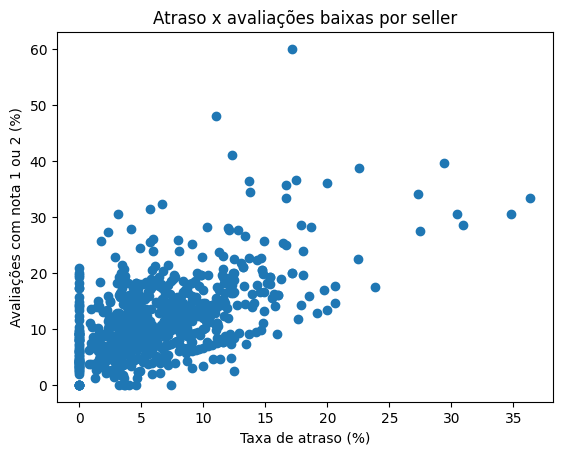

In [232]:
plt.scatter(
    resumo_seller['taxa_atraso'],
    resumo_seller['taxa_avaliacoes_baixas']
)

plt.title('Atraso x avaliações baixas por seller')
plt.xlabel('Taxa de atraso (%)')
plt.ylabel('Avaliações com nota 1 ou 2 (%)')

plt.savefig(
    PASTA_GRAFICOS + '/06_atraso_avaliacoes_baixas_seller.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [168]:
correlacao_sellers = resumo_seller['taxa_atraso'].corr(
    resumo_seller['taxa_avaliacoes_baixas'],
    method='spearman'
)

correlacao_sellers

np.float64(0.4931176331771518)

#### Interpretação

Entre os sellers com pelo menos 22 pedidos, foi observada uma correlação de Spearman de aproximadamente 0,49 entre a taxa de atraso e a proporção de avaliações com notas 1 ou 2.

O resultado indica uma associação positiva: sellers com maior percentual de pedidos atrasados tendem também a apresentar maior percentual de avaliações baixas.

Entretanto, a dispersão observada no gráfico mostra que o atraso não explica sozinho as diferenças de satisfação entre os sellers.


### 6.5 Valor transacionado e sellers de atenção

In [169]:
valor_por_seller = base_sellers_volume.groupby(
    'seller_id'
)['price'].sum()

valor_por_seller.head()

,price
seller_id,
001cca7ae9ae17fb1caed9dfb1094831,24037.13
002100f778ceb8431b7a1020ff7ab48f,1138.90
004c9cd9d87a3c30c522c48c4fc07416,18524.29
00ee68308b45bc5e2660cd833c3f81cc,19231.00
00fc707aaaad2d31347cf883cd2dfe10,11432.40


In [170]:
resumo_seller['valor_transacionado'] = valor_por_seller

In [171]:
resumo_seller.head()

,quantidade_pedidos,taxa_atraso,taxa_avaliacoes_baixas,valor_transacionado
seller_id,,,,
001cca7ae9ae17fb1caed9dfb1094831,191,5.759162,13.612565,24037.13
002100f778ceb8431b7a1020ff7ab48f,47,19.148936,12.765957,1138.90
004c9cd9d87a3c30c522c48c4fc07416,147,5.442177,12.244898,18524.29
00ee68308b45bc5e2660cd833c3f81cc,128,7.812500,10.156250,19231.00
00fc707aaaad2d31347cf883cd2dfe10,94,4.255319,14.893617,11432.40


In [172]:
resumo_seller['valor_transacionado'].describe()

,valor_transacionado
count,738.000000
mean,13961.101572
std,24470.861341
min,345.600000
25%,3641.827500
50%,6606.830000
75%,12831.197500
max,222922.150000


In [173]:
limite_valor_seller = resumo_seller[
    'valor_transacionado'
].quantile(0.75)

limite_valor_seller

np.float64(12831.197499999998)

In [174]:
sellers_maior_valor = resumo_seller[
    resumo_seller['valor_transacionado'] >= limite_valor_seller
]

sellers_maior_valor.shape

(185, 4)

In [175]:
sellers_maior_valor.head()

,quantidade_pedidos,taxa_atraso,taxa_avaliacoes_baixas,valor_transacionado
seller_id,,,,
001cca7ae9ae17fb1caed9dfb1094831,191,5.759162,13.612565,24037.13
004c9cd9d87a3c30c522c48c4fc07416,147,5.442177,12.244898,18524.29
00ee68308b45bc5e2660cd833c3f81cc,128,7.812500,10.156250,19231.00
01fdefa7697d26ad920e9e0346d4bd1b,126,5.555556,5.555556,14640.73
0241d4d5d36f10f80c644447315af0bd,222,4.954955,7.657658,29235.70


In [176]:
sellers_maior_valor[
    ['taxa_atraso', 'taxa_avaliacoes_baixas']
].describe()

,taxa_atraso,taxa_avaliacoes_baixas
count,185.000000,185.000000
mean,6.898164,12.207368
std,4.350634,6.379589
min,0.000000,0.000000
25%,4.000000,7.894737
50%,6.153846,11.041009
75%,8.896797,14.723926
max,34.782609,48.066298


#### Critério para sellers de atenção

Sellers de atenção são aqueles que já pertencem ao grupo de maior valor transacionado e que também apresentam taxa de atraso e taxa de avaliações baixas acima do 75º percentil.


In [177]:
limite_atraso = sellers_maior_valor[
    'taxa_atraso'
].quantile(0.75)

limite_avaliacoes_baixas = sellers_maior_valor[
    'taxa_avaliacoes_baixas'
].quantile(0.75)

print('Limite taxa de atraso:', limite_atraso)
print('Limite avaliações baixas:', limite_avaliacoes_baixas)

Limite taxa de atraso: 8.896797153024911
Limite avaliações baixas: 14.723926380368098


In [178]:
sellers_atencao = sellers_maior_valor[
    (sellers_maior_valor['taxa_atraso'] >= limite_atraso)
    &
    (
        sellers_maior_valor['taxa_avaliacoes_baixas']
        >= limite_avaliacoes_baixas
    )
]

In [179]:
sellers_atencao.shape

(22, 4)

In [180]:
sellers_atencao.head()

,quantidade_pedidos,taxa_atraso,taxa_avaliacoes_baixas,valor_transacionado
seller_id,,,,
06a2c3af7b3aee5d69171b0e14f0ee87,383,18.537859,15.926893,35339.07
1835b56ce799e6a4dc4eddc053f04066,371,11.590296,20.754717,28613.33
1900267e848ceeba8fa32d80c1a5f5a8,351,9.116809,15.954416,21611.17
2eb70248d66e0e3ef83659f71b244378,181,11.049724,48.066298,37360.25
4a3ca9315b744ce9f8e9374361493884,1640,10.000000,16.951220,181949.62


In [181]:
pedidos_sellers_atencao = sellers_atencao[
    'quantidade_pedidos'
].sum()

pedidos_sellers_atencao

np.int64(6710)

In [182]:
valor_sellers_atencao = sellers_atencao[
    'valor_transacionado'
].sum()

valor_sellers_atencao

np.float64(933303.2900000002)

In [183]:
valor_total_sellers = resumo_seller[
    'valor_transacionado'
].sum()

valor_total_sellers

np.float64(10303292.959999999)

In [184]:
percentual_valor_sellers_atencao = (
    valor_sellers_atencao
    /
    valor_total_sellers
    * 100
)

percentual_valor_sellers_atencao

np.float64(9.058301007486836)

In [185]:
sellers_atencao_ordenados = sellers_atencao.sort_values(
    'valor_transacionado',
    ascending=False
)

sellers_atencao_ordenados.head(10)

,quantidade_pedidos,taxa_atraso,taxa_avaliacoes_baixas,valor_transacionado
seller_id,,,,
4a3ca9315b744ce9f8e9374361493884,1640,10.000000,16.951220,181949.62
7c67e1448b00f6e969d365cea6b010ab,951,9.043113,25.236593,181767.11
7d13fca15225358621be4086e1eb0964,545,11.743119,16.330275,109922.71
712e6ed8aa4aa1fa65dab41fed5737e4,75,20.000000,36.000000,38704.00
2eb70248d66e0e3ef83659f71b244378,181,11.049724,48.066298,37360.25
06a2c3af7b3aee5d69171b0e14f0ee87,383,18.537859,15.926893,35339.07
c3867b4666c7d76867627c2f7fb22e21,218,11.009174,15.596330,33645.90
855668e0971d4dfd7bef1b6a4133b41b,290,12.413793,20.000000,30037.26
70a12e78e608ac31179aea7f8422044b,305,9.508197,20.000000,29476.53


### 6.6 Conclusão - Análise de sellers

A análise considerou apenas pedidos associados a um único seller, evitando atribuir uma mesma avaliação a diferentes vendedores do mesmo pedido.

Para reduzir distorções provocadas por sellers com poucas vendas, foram comparados sellers com pelo menos 22 pedidos, totalizando 738 sellers.

Foi observada uma correlação de Spearman de aproximadamente 0,49 entre a taxa de atraso e a proporção de avaliações com notas 1 ou 2, indicando uma associação positiva moderada entre esses indicadores.

Entre os sellers analisados, 22 foram classificados como grupo de atenção por combinarem maior valor transacionado com taxas elevadas de atraso e avaliações baixas.

Esses 22 sellers concentraram aproximadamente 6.710 pedidos e R$ 933 mil em valor transacionado, correspondendo a cerca de 9% do valor movimentado pelos sellers considerados na análise.

O resultado sugere que ações de acompanhamento podem ser direcionadas a um grupo relativamente pequeno de sellers que combina relevância financeira e indicadores de experiência desfavoráveis.


## 7. Frete

O frete é analisado como possível fator complementar relacionado à satisfação e ao atraso.


In [186]:
frete_por_pedido = order_items.groupby(
    'order_id',
    as_index=False
)['freight_value'].sum()

frete_por_pedido.head()

,order_id,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,13.29
1,00018f77f2f0320c557190d7a144bdd3,19.93
2,000229ec398224ef6ca0657da4fc703e,17.87
3,00024acbcdf0a6daa1e931b038114c75,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,18.14


In [187]:
base_frete_satisfacao = pd.merge(
    base_analise,
    frete_por_pedido,
    on='order_id',
    how='inner'
)

In [188]:
base_frete_satisfacao.head()

,order_id,review_score,price,freight_value
0,73fc7af87114b39712e6da79b0a377eb,4,370.00,27.26
1,a548910a1c6147796b98fdf73dbeba33,5,79.79,8.30
2,f9e4b658b201a9f2ecdecbb34bed034b,5,149.00,45.12
3,658677c97b385a9be170737859d3511b,5,179.99,42.85
4,8e6bfb81e283fa7e4f11123a3fb894f1,5,1199.00,134.25


In [189]:
base_frete_satisfacao.shape

(95307, 4)

### 7.1 Frete x satisfação

In [190]:
base_frete_satisfacao.groupby(
    'review_score'
)['freight_value'].mean()

,freight_value
review_score,
1,28.165790
2,26.298514
3,23.580515
4,22.373378
5,21.715876


In [191]:
base_frete_satisfacao.groupby(
    'review_score'
)['freight_value'].median()

,freight_value
review_score,
1,18.79
2,18.02
3,17.63
4,17.19
5,16.79


In [192]:
correlacao_frete = base_frete_satisfacao[
    'review_score'
].corr(
    base_frete_satisfacao['freight_value'],
    method='spearman'
)

correlacao_frete

np.float64(-0.08839089433872804)

#### Interpretação parcial

Os pedidos com avaliações mais baixas apresentaram valores médios e medianos de frete ligeiramente superiores.

Entretanto, a correlação de Spearman entre o valor do frete e a nota de satisfação foi de aproximadamente -0,09, indicando uma associação negativa muito fraca.


### 7.2 Frete x atraso

In [193]:
base_frete_entrega = pd.merge(
    base_entrega_satisfacao,
    frete_por_pedido,
    on='order_id',
    how='inner'
)

In [194]:
correlacao_frete_atraso = base_frete_entrega[
    'freight_value'
].corr(
    base_frete_entrega['diferenca_entrega_dias'],
    method='spearman'
)

correlacao_frete_atraso

np.float64(-0.15660841074317744)

In [195]:
frete_pedidos_atrasados = base_frete_entrega[
    base_frete_entrega['atrasado'] == True
]

In [196]:
frete_pedidos_atrasados.shape

(6353, 5)

In [197]:
correlacao_frete_dias_atraso = frete_pedidos_atrasados[
    'freight_value'
].corr(
    frete_pedidos_atrasados['diferenca_entrega_dias'],
    method='spearman'
)

correlacao_frete_dias_atraso

np.float64(0.1258739165321769)

### 7.3 Conclusão - Frete

Os pedidos com avaliações mais baixas apresentaram valores médios e medianos de frete um pouco maiores.

Entretanto, a correlação de Spearman entre frete e satisfação foi de aproximadamente -0,09, indicando uma associação muito fraca.

Entre os pedidos atrasados, a correlação entre o valor do frete e a quantidade de dias de atraso foi de aproximadamente 0,13, também indicando uma associação fraca.

Dessa forma, o valor do frete será considerado um fator complementar, mas não aparece como um dos principais fatores associados à satisfação ou ao atraso na base analisada.


## 8. Evolução comercial

A análise temporal observa a evolução dos pedidos entregues, do valor transacionado e do valor médio por pedido.


### 8.1 Pedidos e valor transacionado por mês

In [198]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

In [199]:
orders['order_purchase_timestamp'].dtype

dtype('<M8[ns]')

In [200]:
orders['ano_compra'] = orders['order_purchase_timestamp'].dt.year
orders['mes_compra'] = orders['order_purchase_timestamp'].dt.month

In [201]:
orders[
    ['order_purchase_timestamp', 'ano_compra', 'mes_compra']
].head()

,order_purchase_timestamp,ano_compra,mes_compra
0,2017-10-02 10:56:33,2017,10
1,2018-07-24 20:41:37,2018,7
2,2018-08-08 08:38:49,2018,8
3,2017-11-18 19:28:06,2017,11
4,2018-02-13 21:18:39,2018,2


In [202]:
base_tempo = pd.merge(
    orders,
    valor_por_pedido,
    on='order_id',
    how='inner'
)

In [203]:
base_tempo.shape

(98666, 11)

In [204]:
base_tempo.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,ano_compra,mes_compra,price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,19.90


In [205]:
base_tempo_entregues = base_tempo[
    base_tempo['order_status'] == 'delivered'
]

base_tempo_entregues.shape

(96478, 11)

In [206]:
pedidos_por_mes = base_tempo_entregues.groupby(
    ['ano_compra', 'mes_compra']
)['order_id'].count()

pedidos_por_mes

ano_compra  mes_compra
2016        9                1
            10             265
            12               1
2017        1              750
            2             1653
            3             2546
            4             2303
            5             3546
            6             3135
            7             3872
            8             4193
            9             4150
            10            4478
            11            7289
            12            5513
2018        1             7069
            2             6555
            3             7003
            4             6798
            5             6749
            6             6099
            7             6159
            8             6351
Name: order_id, dtype: int64

In [207]:
valor_por_mes = base_tempo_entregues.groupby(
    ['ano_compra', 'mes_compra']
)['price'].sum()

valor_por_mes

ano_compra  mes_compra
2016        9                134.97
            10             40325.11
            12                10.90
2017        1             111798.36
            2             234223.40
            3             359198.85
            4             340669.68
            5             489338.25
            6             421923.37
            7             481604.52
            8             554699.70
            9             607399.67
            10            648247.65
            11            987765.37
            12            726033.19
2018        1             924645.00
            2             826437.13
            3             953356.25
            4             973534.09
            5             977544.69
            6             856077.86
            7             867953.46
            8             838576.64
Name: price, dtype: float64

In [208]:
base_tempo_entregues.shape

(96478, 11)

In [209]:
pedidos_por_mes

ano_compra  mes_compra
2016        9                1
            10             265
            12               1
2017        1              750
            2             1653
            3             2546
            4             2303
            5             3546
            6             3135
            7             3872
            8             4193
            9             4150
            10            4478
            11            7289
            12            5513
2018        1             7069
            2             6555
            3             7003
            4             6798
            5             6749
            6             6099
            7             6159
            8             6351
Name: order_id, dtype: int64

In [210]:
base_tempo_entregues['periodo'] = (
    base_tempo_entregues['order_purchase_timestamp']
    .dt.to_period('M')
)

/tmp/ipykernel_2395/3365831124.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base_tempo_entregues['periodo'] = (


In [211]:
base_tempo_entregues[
    ['order_purchase_timestamp', 'periodo']
].head()

,order_purchase_timestamp,periodo
0,2017-10-02 10:56:33,2017-10
1,2018-07-24 20:41:37,2018-07
2,2018-08-08 08:38:49,2018-08
3,2017-11-18 19:28:06,2017-11
4,2018-02-13 21:18:39,2018-02


In [212]:
evolucao_pedidos = base_tempo_entregues.groupby(
    'periodo'
)['order_id'].count()

evolucao_pedidos

,order_id
periodo,
2016-09,1
2016-10,265
2016-12,1
2017-01,750
2017-02,1653
2017-03,2546
2017-04,2303
2017-05,3546
2017-06,3135


In [213]:
evolucao_valor = base_tempo_entregues.groupby(
    'periodo'
)['price'].sum()

evolucao_valor

,price
periodo,
2016-09,134.97
2016-10,40325.11
2016-12,10.90
2017-01,111798.36
2017-02,234223.40
2017-03,359198.85
2017-04,340669.68
2017-05,489338.25
2017-06,421923.37


In [214]:
evolucao_pedidos_2017 = evolucao_pedidos[
    evolucao_pedidos.index >= '2017-01'
]

evolucao_valor_2017 = evolucao_valor[
    evolucao_valor.index >= '2017-01'
]

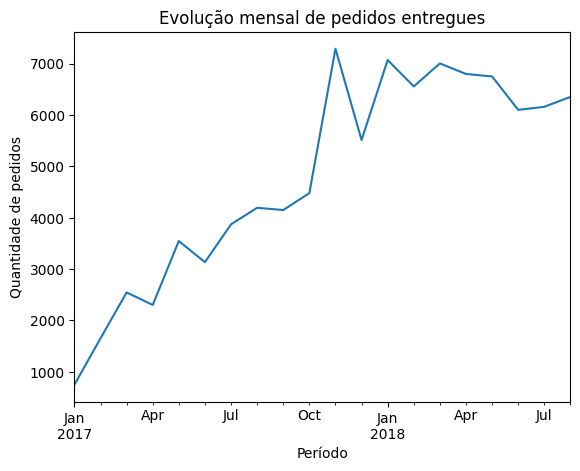

In [233]:
evolucao_pedidos_2017.plot.line()

plt.title('Evolução mensal de pedidos entregues')
plt.xlabel('Período')
plt.ylabel('Quantidade de pedidos')

plt.savefig(
    PASTA_GRAFICOS + '/08_evolucao_mensal_pedidos.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

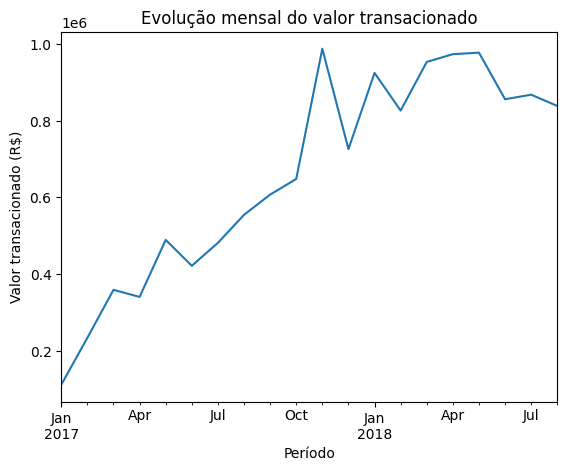

In [236]:
evolucao_valor_2017.plot.line()

plt.title('Evolução mensal do valor transacionado')
plt.xlabel('Período')
plt.ylabel('Valor transacionado (R$)')

plt.savefig(
    PASTA_GRAFICOS + '/08_evolucao_mensal_valor.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#### Leitura dos gráficos de pedidos e valor

Os dados de 2016 aparecem de forma esparsa e, por isso, não foram utilizados como principal referência para a análise temporal.

A partir de janeiro de 2017, observa-se crescimento expressivo na quantidade de pedidos entregues e no valor transacionado, com destaque para novembro de 2017, que apresentou 7.289 pedidos e aproximadamente R$ 988 mil em produtos.

Ao longo de 2018, o volume mensal permaneceu em um patamar superior ao observado no início de 2017, oscilando em torno de 6 mil a 7 mil pedidos por mês até agosto.

O valor transacionado apresentou comportamento semelhante ao volume de pedidos, sugerindo que parte importante de sua evolução está associada ao crescimento da quantidade de pedidos.


### 8.2 Valor médio por pedido

#### O valor cresceu porque os pedidos ficaram mais caros ou simplesmente porque tivemos mais pedidos?


In [217]:
ticket_medio_mes = (
    evolucao_valor
    /
    evolucao_pedidos
)

ticket_medio_mes

,0
periodo,
2016-09,134.970000
2016-10,152.170226
2016-12,10.900000
2017-01,149.064480
2017-02,141.695947
2017-03,141.083602
2017-04,147.924307
2017-05,137.997250
2017-06,134.584807


In [218]:
ticket_medio_2017 = ticket_medio_mes[
    ticket_medio_mes.index >= '2017-01'
]

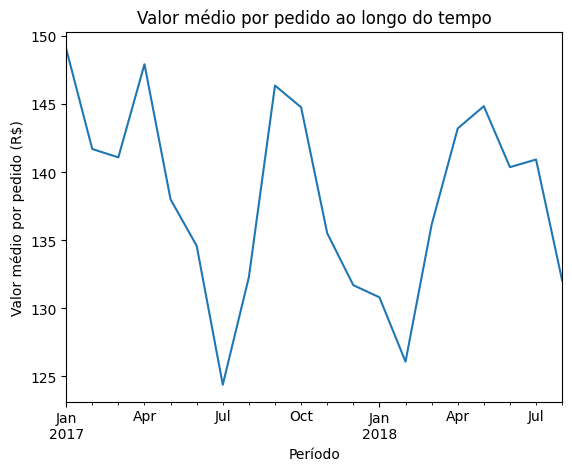

In [219]:
ticket_medio_2017.plot.line()

plt.title('Valor médio por pedido ao longo do tempo')
plt.xlabel('Período')
plt.ylabel('Valor médio por pedido (R$)')

plt.show()

#### Leitura do valor médio por pedido

O valor médio por pedido não apresentou uma tendência clara de crescimento, permanecendo relativamente estável e oscilando ao longo do período.

Esse comportamento sugere que o crescimento do valor transacionado esteve mais relacionado ao aumento da quantidade de pedidos do que ao aumento do valor médio de cada compra.


### 8.3 Relação entre quantidade de pedidos e valor transacionado

In [220]:
evolucao_comercial = pd.concat(
    [
        evolucao_pedidos_2017,
        evolucao_valor_2017
    ],
    axis=1
)

evolucao_comercial.columns = [
    'quantidade_pedidos',
    'valor_transacionado'
]

evolucao_comercial

,quantidade_pedidos,valor_transacionado
periodo,,
2017-01,750,111798.36
2017-02,1653,234223.40
2017-03,2546,359198.85
2017-04,2303,340669.68
2017-05,3546,489338.25
2017-06,3135,421923.37
2017-07,3872,481604.52
2017-08,4193,554699.70
2017-09,4150,607399.67


In [221]:
correlacao_pedidos_valor = evolucao_comercial[
    'quantidade_pedidos'
].corr(
    evolucao_comercial['valor_transacionado'],
    method='spearman'
)

correlacao_pedidos_valor

np.float64(0.9684210526315788)

### 8.4 Conclusão - Performance comercial ao longo do tempo

A quantidade de pedidos entregues cresceu de forma expressiva ao longo de 2017, acompanhada pelo aumento do valor transacionado.

Em 2018, ambos permaneceram em um patamar mensal elevado, embora com oscilações entre os meses.

O valor médio por pedido não apresentou uma tendência contínua de crescimento, indicando que a evolução do valor transacionado esteve mais associada ao aumento do volume de pedidos.

A correlação de Spearman entre a quantidade mensal de pedidos e o valor transacionado foi de aproximadamente 0,97, reforçando a forte associação entre essas duas medidas no período analisado.


## 9. Síntese dos principais achados

A análise partiu da pergunta inicial:

**Clientes mais satisfeitos apresentam pedidos de maior valor?**

Os dados não confirmaram essa hipótese inicial. Ao longo da exploração,
outros fatores apresentaram relações mais relevantes com a satisfação dos clientes.

1. **Valor do pedido x satisfação**

   O valor dos pedidos não apresentou relação relevante com a nota de satisfação.

   A correlação de Spearman foi de aproximadamente **-0,03**, valor muito próximo
   de zero. Além disso, os pedidos com nota 1 apresentaram mediana de R$ 99,00,
   enquanto os pedidos com notas 4 e 5 apresentaram medianas próximas de R$ 84,00.

   Portanto, não foi encontrada evidência de que pedidos de maior valor estejam
   associados a clientes mais satisfeitos.

2. **Prazo de entrega x satisfação**

   O cumprimento do prazo apresentou uma relação muito mais clara com a satisfação.

   Pedidos sem atraso tiveram nota média de aproximadamente **4,29** e mediana 5,
   enquanto pedidos atrasados apresentaram média de aproximadamente **2,27**
   e mediana 1.

   Além disso, cerca de **62% dos pedidos atrasados receberam notas 1 ou 2**,
   contra aproximadamente **9% dos pedidos sem atraso**.

3. **Tamanho do atraso x satisfação**

   Entre os pedidos atrasados, a correlação de Spearman entre dias de atraso
   e nota de satisfação foi de aproximadamente **-0,40**.

   Nos atrasos de 1 a 3 dias, cerca de 32% dos pedidos receberam notas 1 ou 2.
   Entre 4 e 7 dias, esse percentual subiu para aproximadamente 68%.
   Nos atrasos superiores a 8 dias, ficou próximo de 80%.

   Os resultados indicam que atrasos maiores tendem a estar associados
   a avaliações mais baixas.

4. **Diferenças entre estados**

   As taxas de atraso e de avaliações baixas variam entre os estados.

   A correlação de Spearman entre a taxa de atraso dos estados e a proporção
   de avaliações com notas 1 ou 2 foi de aproximadamente **0,83**,
   indicando uma associação positiva forte.

   Entretanto, os estados possuem volumes muito diferentes e, por isso,
   as taxas precisam ser analisadas juntamente com a quantidade de pedidos
   e o valor transacionado.

   O Rio de Janeiro se destacou por combinar alto volume de pedidos,
   valor transacionado relevante e indicadores de atraso e insatisfação
   superiores aos observados em estados de volume semelhante, como Minas Gerais.

5. **Valor associado a experiências negativas**

   Foram identificados **3.962 pedidos** que apresentaram simultaneamente
   atraso na entrega e avaliação com nota 1 ou 2.

   Esses pedidos somaram aproximadamente **R$ 616 mil em valor transacionado**,
   representando cerca de **4,7% do valor total analisado**.

   Esse montante não representa receita perdida, mas mostra a dimensão financeira
   associada a pedidos que apresentaram sinais de experiência negativa.

6. **Análise dos sellers**

   Para evitar atribuir uma mesma avaliação a diferentes vendedores,
   a análise considerou apenas pedidos associados a um único seller.

   Entre os sellers com volume suficiente para comparação, foi encontrada
   correlação de aproximadamente **0,49** entre taxa de atraso e proporção
   de avaliações baixas.

   Um grupo de **22 sellers** foi identificado por combinar maior valor
   transacionado com taxas elevadas de atraso e avaliações 1 ou 2.

   Esses sellers concentraram **6.710 pedidos** e aproximadamente
   **R$ 933 mil em valor transacionado**.

7. **Frete**

   Os pedidos com notas menores apresentaram fretes médios um pouco maiores,
   porém a correlação entre frete e satisfação foi de apenas aproximadamente
   **-0,09**.

   Entre pedidos atrasados, a correlação entre frete e quantidade de dias
   de atraso também foi fraca, aproximadamente **0,13**.

   Dessa forma, o frete aparece como fator complementar, mas não como
   um dos principais fatores associados à insatisfação.

8. **Evolução comercial**

   A quantidade de pedidos e o valor transacionado cresceram de forma expressiva
   ao longo de 2017.

   Em 2018, ambos permaneceram em um patamar mensal elevado, embora com oscilações.

   O valor médio por pedido não apresentou uma tendência contínua de crescimento.
   A correlação entre quantidade mensal de pedidos e valor transacionado foi
   aproximadamente **0,97**.

   Os resultados indicam que a evolução do valor transacionado esteve mais
   associada ao aumento da quantidade de pedidos do que ao aumento do valor
   médio de cada compra.

### 9.1 Conclusão geral

A hipótese inicial de que clientes mais satisfeitos estariam associados a pedidos
de maior valor não foi sustentada pelos dados.

Por outro lado, a análise mostrou uma associação relevante entre o desempenho
logístico e a satisfação dos clientes, principalmente em relação ao cumprimento
do prazo de entrega.

O problema também não ocorre com a mesma intensidade em todos os estados e sellers.
Ao combinar indicadores de experiência com volume de pedidos e valor transacionado,
é possível identificar pontos de maior atenção e direcionar ações de forma mais
priorizada.

Assim, os resultados sugerem que iniciativas voltadas à redução de atrasos,
com atenção especial a localidades e sellers de maior relevância operacional
e financeira, representam uma oportunidade mais consistente do que ações
baseadas apenas no valor dos pedidos.

## 10. Recomendações

### 10.1 Redução de atrasos de entrega

Priorizar iniciativas voltadas à redução de atrasos, especialmente nos casos
em que o prazo ultrapassa 4 dias.

Os pedidos atrasados apresentaram avaliações significativamente menores e
maior concentração de notas 1 ou 2. A partir da faixa de 4 a 7 dias de atraso,
aproximadamente 68% dos pedidos receberam avaliações baixas, percentual que
permaneceu próximo de 80% nos atrasos superiores a 8 dias.

Como ação, recomenda-se acompanhar taxa e quantidade de dias de atraso
por região e seller, direcionando a investigação para os grupos com maior
incidência e relevância operacional.

### 10.2 Priorização regional baseada em exposição

As ações não devem considerar apenas a taxa de atraso de cada estado,
mas também o volume de pedidos e o valor transacionado.

No recorte analisado, o Rio de Janeiro apresentou uma combinação relevante
de alto volume, valor transacionado elevado e indicadores de atraso e
avaliações baixas acima dos observados em estados de volume semelhante.

Recomenda-se utilizar esses indicadores de forma conjunta para definir
regiões prioritárias para investigação e melhoria operacional.

### 10.3 Acompanhamento de sellers de atenção

Foi identificado um grupo de 22 sellers que combinam maior valor
transacionado com taxas elevadas de atraso e avaliações baixas.

Esses sellers concentraram 6.710 pedidos e aproximadamente R$ 933 mil
em valor transacionado.

Recomenda-se criar acompanhamento periódico desse grupo, utilizando
indicadores de volume, atraso, satisfação e valor transacionado para apoiar
ações de melhoria e monitoramento.

### 10.4 Foco nos fatores com maior associação à satisfação

O valor dos pedidos e o valor do frete apresentaram associações muito fracas
com a satisfação dos clientes.

Por outro lado, o cumprimento do prazo de entrega apresentou relação
consideravelmente mais forte com as avaliações.

Dessa forma, recomenda-se priorizar inicialmente ações relacionadas ao
desempenho logístico, utilizando preço e frete como fatores complementares
e não como principais direcionadores das iniciativas de satisfação.

### 10.5 Direcionamento

Os resultados sugerem uma estratégia de priorização baseada em três dimensões:

**atraso de entrega + relevância financeira + concentração em regiões e sellers.**

Essa combinação permite direcionar ações para os pontos em que a experiência
negativa ocorre com maior relevância para a operação.

## 11. Exportação dos resultados da análise

Nesta etapa, serão salvas as principais bases analíticas construídas durante
a exploração dos dados.

Esses arquivos serão utilizados posteriormente para a construção das
visualizações e do storytelling executivo, evitando repetir toda a etapa
de preparação dos dados.

In [222]:
PASTA_OUTPUTS = '/content/drive/MyDrive/Tech_Challenge_Fase1/outputs'

In [223]:
base_analise.to_csv(
    PASTA_OUTPUTS + '/base_satisfacao_valor.csv',
    index=False
)

base_entrega_satisfacao.to_csv(
    PASTA_OUTPUTS + '/base_entrega_satisfacao.csv',
    index=False
)

resumo_estado.to_csv(
    PASTA_OUTPUTS + '/resumo_estado.csv',
    index=True,
    index_label='customer_state'
)

resumo_seller.to_csv(
    PASTA_OUTPUTS + '/resumo_seller.csv',
    index=True,
    index_label='seller_id'
)

sellers_atencao_ordenados.to_csv(
    PASTA_OUTPUTS + '/sellers_atencao.csv',
    index=True,
    index_label='seller_id'
)

evolucao_comercial.to_csv(
    PASTA_OUTPUTS + '/evolucao_comercial.csv',
    index=True,
    index_label='periodo'
)

In [224]:
import os

os.listdir(PASTA_OUTPUTS)

['tables',
 'base_satisfacao_valor.csv',
 'base_entrega_satisfacao.csv',
 'resumo_estado.csv',
 'resumo_seller.csv',
 'sellers_atencao.csv',
 'evolucao_comercial.csv']